# Clusterização

Este notebook aplica os três algoritmos previstos no método (K-means,
hierárquico de Ward e DBSCAN) sobre a mesma matriz, o `matriz_modelagem.csv`
produzido no notebook 03, e mede a qualidade de cada partição, isto é, de
cada divisão dos 644 municípios em grupos. Responde à parte de qualidade
estatística da pergunta (ii) do artigo.

Saídas:

- **Figura 4** do artigo (`figura4_selecao_k`): as quatro medidas de
  qualidade do K-means e do Ward para k de 2 a 10;
- `data/processed/metricas_clusterizacao.csv`: a tabela dessas medidas;
- `data/processed/dbscan_grade.csv`: as configurações testadas do DBSCAN;
- figuras de apoio: `figura_dendrograma` e `figura_k_distancia`.

**Este notebook apenas mede.** A escolha do modelo é feita no notebook 05,
com uma regra de decisão definida pelo grupo antes de conhecer estes números
e que combina qualidade, estabilidade e interpretabilidade.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Os notebooks ficam em notebooks/ e o código do projeto em src/. Estas duas
# linhas apontam o Python para src/, para os "from config import ..." abaixo
# funcionarem tanto rodando daqui quanto da raiz do projeto.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from config import (DATA_PROCESSED, DICIONARIO_CSV, QUANTIS_EPS_DBSCAN,
                    VARIANCIA_PCA_DBSCAN)
from estilo import aplicar_estilo, salvar
from figuras import plot_dendrograma, plot_k_distancia, plot_selecao_k
from preprocessamento import carregar_features
from clusterizacao import (componentes_pca, distancia_k_vizinho,
                           grade_dbscan, metricas_por_k)

aplicar_estilo()   # mesma fonte, cores e grade em todas as figuras do artigo
# Se algum import acima falhar, quase sempre é o editor apontando para outra
# instalação do Python. O caminho impresso aqui é o que precisa ter as
# bibliotecas do requirements.txt.
print("Python:", sys.executable)

# O código do IBGE é identificador, não quantidade: lido como texto para não
# virar número em nenhuma etapa.
matriz = pd.read_csv(DATA_PROCESSED / "matriz_modelagem.csv",
                     dtype={"codigo_ibge": str})
dic = pd.read_csv(DICIONARIO_CSV)

Python: C:\Users\Higor\Documents\6 Sem\RP2\projeto\database-rp2\.venv\Scripts\python.exe


## 1. Matriz de entrada

A matriz já chega transformada, padronizada e ponderada pelo notebook 03. As
conferências abaixo garantem que se trata do mesmo arquivo: 644 municípios,
as 22 features na ordem do dicionário e nenhum valor ausente.

In [2]:
features, bloco_de = carregar_features(dic)

# Só as 22 features entram no agrupamento; código e nome ficam de fora.
W = matriz[features]
assert len(W) == 644, "a matriz deveria ter os 644 municípios sem a capital"
# As colunas do arquivo, tirando as duas de identificação, têm que ser as
# features do dicionário, na mesma ordem.
assert list(matriz.columns[2:]) == features, "colunas fora da ordem do dicionário"
assert not W.isna().any().any(), "há valores ausentes na matriz"
print(f"{W.shape[0]} municípios | {W.shape[1]} features")

644 municípios | 22 features


## 2. Os três algoritmos

**K-means.** Forma k grupos em volta de k centros. O número de grupos k é
definido pelo analista; o algoritmo sorteia os centros iniciais, associa cada
município ao centro mais próximo, move cada centro para a média do seu grupo
e repete até que nada mude. Como o resultado depende do sorteio inicial, o
procedimento é repetido 50 vezes e a melhor solução é mantida.

**Hierárquico de Ward.** Começa com cada município em um grupo próprio e, a
cada passo, junta os dois grupos mais parecidos, isto é, aqueles cuja união
menos aumenta a dispersão interna. O processo forma uma árvore (o
dendrograma), e cortar a árvore em uma altura determinada produz k grupos.
Não envolve sorteio: os mesmos dados produzem sempre a mesma árvore.

**DBSCAN.** Procura regiões com muitos municípios próximos uns dos outros.
Um município com pelo menos `min_pts` vizinhos dentro de um raio `eps` está
em região densa; regiões densas que se tocam formam um grupo, e os municípios
isolados são classificados como ruído. O número de grupos não é definido de
antemão: é consequência de `eps` e `min_pts`.

## 3. K-means e Ward para k de 2 a 10

Cada partição é avaliada por quatro medidas:

- **Soma dos quadrados interna**: quanto os municípios estão espalhados em
  torno da média do próprio grupo. Sempre diminui quando k aumenta, de modo
  que não se procura o menor valor, mas o "cotovelo", ponto a partir do qual
  a queda perde força.
- **Silhueta**: compara, para cada município, a distância média aos membros
  do próprio grupo com a distância média aos do grupo vizinho mais próximo.
  Vai de −1 a 1; **maior é melhor**.
- **Calinski–Harabasz**: razão entre a dispersão entre os grupos e a
  dispersão dentro deles. **Maior é melhor**.
- **Davies–Bouldin**: média, entre os grupos, da semelhança de cada um com
  o grupo mais parecido com ele. **Menor é melhor**.

As colunas `menor_grupo` e `maior_grupo` registram o tamanho, em municípios,
do menor e do maior grupo de cada partição.

In [3]:
metricas = metricas_por_k(W)
metricas.to_csv(DATA_PROCESSED / "metricas_clusterizacao.csv", index=False)
metricas.round(3)

,algoritmo,k,soma_quadrados,silhueta,calinski_harabasz,davies_bouldin,menor_grupo,maior_grupo
0,kmeans,2,1629.824,0.136,119.029,2.216,302,342
1,kmeans,3,1500.705,0.129,92.110,2.210,76,290
2,kmeans,4,1389.916,0.101,83.203,2.169,66,217
3,kmeans,5,1327.847,0.090,72.684,2.373,67,204
4,kmeans,6,1283.396,0.088,64.487,2.394,64,164
5,kmeans,7,1248.163,0.089,58.166,2.326,21,156
6,kmeans,8,1217.580,0.084,53.311,2.253,23,145
7,kmeans,9,1188.609,0.077,49.643,2.311,21,116
8,kmeans,10,1164.844,0.073,46.394,2.336,20,111
9,ward,2,1670.395,0.114,100.546,2.297,238,406


WindowsPath('C:/Users/Higor/Documents/6 Sem/RP2/projeto/database-rp2/figuras/figura4_selecao_k.png')

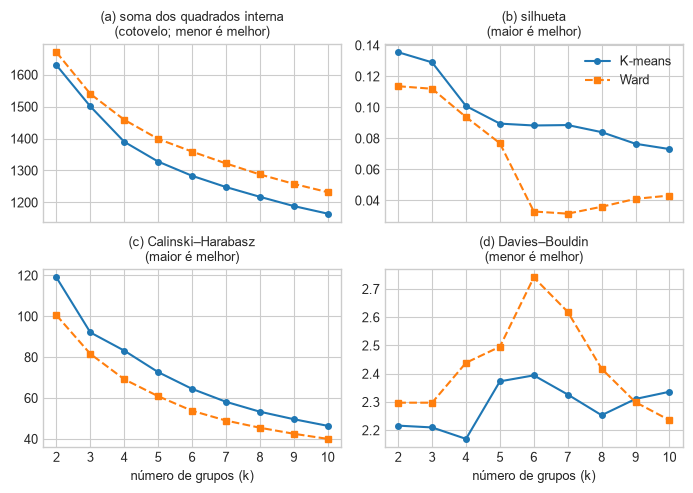

In [4]:
fig = plot_selecao_k(metricas)
salvar(fig, "figura4_selecao_k")

## 4. Dendrograma

O dendrograma representa a sequência de junções do Ward. O eixo horizontal
traz os ramos (para manter a figura legível, apenas as 30 últimas junções
aparecem, e o número entre parênteses indica quantos municípios cada ramo
reúne); o eixo vertical traz o custo de cada fusão, isto é, o quanto a
dispersão interna aumentou ao juntar os dois ramos.

Cortar a árvore com uma linha horizontal produz tantos grupos quantos ramos a
linha cruzar. Saltos grandes de altura indicam fusões de grupos muito
diferentes, e cortar logo abaixo deles separa grupos bem distintos; alturas
próximas umas das outras indicam que os cortes dividem uma nuvem contínua.

WindowsPath('C:/Users/Higor/Documents/6 Sem/RP2/projeto/database-rp2/figuras/figura_dendrograma.png')

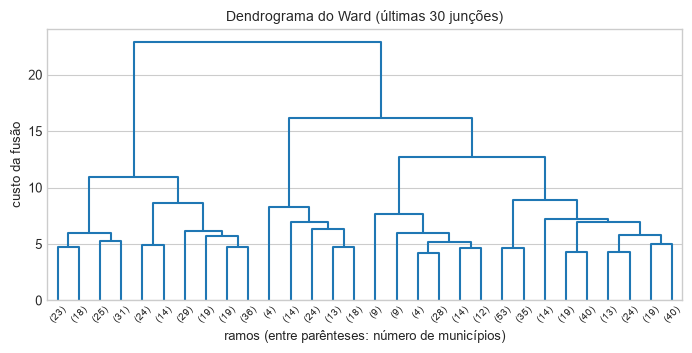

In [5]:
fig = plot_dendrograma(W)
salvar(fig, "figura_dendrograma")

O maior salto de altura está na última junção, que une os dois grandes
ramos da árvore (um de 238 e outro de 406 municípios, os mesmos tamanhos da
partição do Ward com k = 2 na tabela da seção 3). Abaixo dela, as junções se
sucedem em alturas cada vez mais próximas, sem um segundo salto que se
destaque, o que é compatível com uma nuvem contínua de municípios.

## 5. DBSCAN

O DBSCAN não opera sobre as 22 colunas, e sim sobre as componentes do PCA
(Análise de Componentes Principais) que somam 80% da variação. Com muitas
colunas, as distâncias entre os municípios ficam parecidas demais entre si,
e a noção de "região densa", na qual o método se apoia, deixa de fazer
sentido. O notebook 03 registrou esse alerta antes da execução. Reduzir a
matriz às componentes principais diminui o problema sem descartar a maior
parte da informação; o `assert` confere que são as mesmas 12 componentes
citadas no artigo.

Os dois parâmetros são escolhidos por regras práticas comuns:

- `min_pts`, o número mínimo de vizinhos de um município em região densa:
  são testados `d + 1` e `2d`, sendo `d` o número de componentes;
- `eps`, o raio: a **curva de k-distância** ordena os municípios pela
  distância ao seu `min_pts`-ésimo vizinho, e um "joelho" nessa curva indica
  o raio que separa as regiões densas do ruído. São testados como `eps` os
  quantis 0,50 a 0,99 da curva.

In [6]:
X = componentes_pca(W, VARIANCIA_PCA_DBSCAN)
assert X.shape[1] == 12, "o artigo cita 12 componentes para 80% da variância"
d = X.shape[1]
min_pts_lista = [d + 1, 2 * d]
print(f"{d} componentes | min_pts testados: {min_pts_lista}")

12 componentes | min_pts testados: [13, 24]


WindowsPath('C:/Users/Higor/Documents/6 Sem/RP2/projeto/database-rp2/figuras/figura_k_distancia.png')

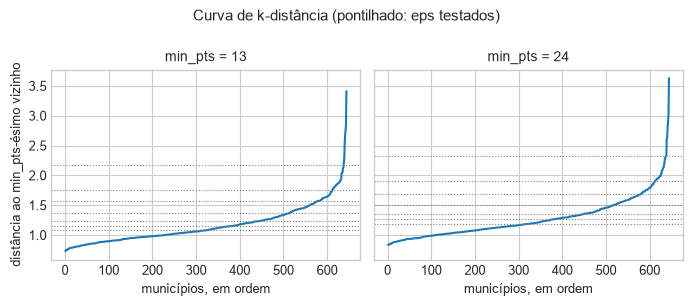

In [7]:
# Uma curva de k-distância por min_pts, com os raios testados em cada uma.
# np.quantile(curva, q) é o valor abaixo do qual fica a fração q da curva.
curvas = {m: distancia_k_vizinho(X, m) for m in min_pts_lista}
eps_testados = {m: [np.quantile(c, q) for q in QUANTIS_EPS_DBSCAN]
                for m, c in curvas.items()}
fig = plot_k_distancia(curvas, eps_testados)
salvar(fig, "figura_k_distancia")

In [8]:
grade = grade_dbscan(X, min_pts_lista, QUANTIS_EPS_DBSCAN)
grade.to_csv(DATA_PROCESSED / "dbscan_grade.csv", index=False)
grade.round(3)

,min_pts,quantil,eps,n_grupos,pct_ruido,maior_grupo_pct,silhueta
0,13,0.50,1.079,1,23.758,76.242,NaN
1,13,0.60,1.156,1,17.547,82.453,NaN
2,13,0.70,1.243,1,11.491,88.509,NaN
3,13,0.80,1.371,1,5.745,94.255,NaN
4,13,0.90,1.572,1,2.329,97.671,NaN
5,13,0.95,1.754,1,1.087,98.913,NaN
6,13,0.99,2.180,1,0.466,99.534,NaN
7,24,0.50,1.187,1,19.410,80.590,NaN
8,24,0.60,1.272,1,14.286,85.714,NaN
9,24,0.70,1.357,1,8.385,91.615,NaN


Em nenhuma das 14 configurações o DBSCAN encontrou mais de um grupo. Com
o raio do quantil 0,50, até 23,8% dos municípios ficam como ruído e os demais
formam um grupo único; com o raio do quantil 0,99, o ruído cai para 0,5%
(`min_pts` = 13) e 0,3% (`min_pts` = 24), e o grupo único passa a conter
quase todos os municípios. Como a silhueta exige pelo menos dois grupos, ela
não pôde ser calculada (`NaN`).

A curva de k-distância explica o resultado: ela sobe de forma gradual, sem
joelho, e só dispara nos últimos municípios, que estão afastados de todos os
outros. Não há, portanto, um nível de densidade que separe regiões densas de
regiões vazias, e sim uma única região, mais densa no centro e mais rarefeita
nas bordas. É o cenário antecipado no notebook 03 e coerente com a nuvem
contínua observada no gráfico das duas primeiras componentes daquele
notebook.

## 6. Resumo

A tabela abaixo reúne, para cada algoritmo, o k com o melhor valor em cada
medida. A soma dos quadrados fica de fora por diminuir sempre com k. A
tabela é apenas descritiva: a escolha do modelo segue a regra do
notebook 05.

In [9]:
# Para cada medida, o sentido em que ela melhora.
sentido = {"silhueta": "maior", "calinski_harabasz": "maior",
           "davies_bouldin": "menor"}
linhas = []
for algoritmo, m in metricas.groupby("algoritmo"):
    for medida, melhor in sentido.items():
        # idxmax/idxmin devolvem o número da linha com o maior/menor valor.
        i = m[medida].idxmax() if melhor == "maior" else m[medida].idxmin()
        linhas.append({"algoritmo": algoritmo, "medida": medida,
                       "melhor": melhor, "k": m.loc[i, "k"],
                       "valor": round(m.loc[i, medida], 3),
                       "menor_grupo": m.loc[i, "menor_grupo"]})
resumo = pd.DataFrame(linhas)

# O DBSCAN não tem k: o que se resume é quantos grupos ele encontrou.
print(f"DBSCAN: no máximo {grade['n_grupos'].max()} grupo(s) nas "
      f"{len(grade)} configurações; ruído entre "
      f"{grade['pct_ruido'].min():.1f}% e {grade['pct_ruido'].max():.1f}%")
resumo

DBSCAN: no máximo 1 grupo(s) nas 14 configurações; ruído entre 0.3% e 23.8%


,algoritmo,medida,melhor,k,valor,menor_grupo
0,kmeans,silhueta,maior,2,0.136,302
1,kmeans,calinski_harabasz,maior,2,119.029,302
2,kmeans,davies_bouldin,menor,4,2.169,66
3,ward,silhueta,maior,2,0.114,238
4,ward,calinski_harabasz,maior,2,100.546,238
5,ward,davies_bouldin,menor,10,2.236,4


Os números permitem as seguintes constatações, todas descritivas:

1. **As silhuetas são baixas em todas as partições.** A maior é 0,136
   (K-means com k = 2), abaixo de 0,25. O resultado não indica erro: o
   notebook 03 mostrou que os municípios formam uma nuvem contínua, sem
   grupos isolados. Nesse cenário, qualquer partição é um corte dentro de um
   gradiente, com muitos municípios perto da fronteira entre dois grupos.
2. **Silhueta e Calinski–Harabasz apontam k = 2 nos dois algoritmos** e
   diminuem à medida que k aumenta. O Davies–Bouldin aponta k = 4 no K-means e
   k = 10 no Ward, este último com um grupo de apenas 4 municípios.
3. **O K-means supera o Ward em silhueta e em Calinski–Harabasz em todos os
   k testados** (tabela da seção 3). No Davies–Bouldin, supera de k = 2 a
   k = 8. Na soma dos quadrados (painel a da Figura 4), a queda do K-means
   perde força a partir de k = 4, enquanto a do Ward é mais gradual; nenhum
   dos dois apresenta um cotovelo nítido.
4. **Grupos pequenos aparecem com k alto.** O menor grupo fica abaixo de 5%
   dos municípios a partir de k = 7 no K-means (21 municípios) e de k = 8 no
   Ward (4 municípios).
5. **O DBSCAN não produziu partição** em nenhuma das configurações testadas.

A seleção entre esses candidatos, que combina estas medidas com a
estabilidade e a interpretabilidade, é feita no notebook 05.